## Introduction

In [ ]:
#Mount your personal Google Drive to colab
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('drive')
os.chdir('MyDrive')

Mounted at /content/drive


In [ ]:
if not os.path.isdir("AI_for_IA"): #create subfolder AI_for_IA if it does
  os.mkdir("AI_for_IA") # not already exist
os.chdir("AI_for_IA") #move into the new subfolder => current working directory
os.getcwd() #check which is the current working directory

'/content/drive/MyDrive/AI_for_IA'

# **Problem B.1 - Step size**

The step size starts out as n but it changes through out the execution of the program. When the program runs it will change based on the output of the term ||f(xt)||. That term will get smaller and smaller based on the direction of which its pointing. It helps to narrow down quickly until it's starting to reach an excact value.
It starts big and ends small.

# **Problem B.2 - Stopping criteria**
 1.   The first, as mentioned, is to stop when a certain number of itterations has been reached.
2.   The second is when the computer reaches an almost exact number. Example, when its within 0,000001 of the correct answer.
3. When a certain amount of time has passed. You can set a stop for when it has past 10 seconds and return the guess where it's at then.

The problem with method 1 and 3 is that if it reaches an exact number before the itteration/time is up, it wil continue until it has reached the desired value. Also, if the number of iterations is up it will give a guess of where it's at and it might be way of.

It can detect if it's a non convergence/divergence because it wont find an answer within said time frame. If it does not find an answer, there isn't one. The code won't run infinitly because it has a max criteria.

With method 2 it will always find a value and answer to the question with an accurate result that's pre-defined by the user. The problem arises when it tries to calculate too accurate of a value resulting that it can't quite reach it. The will result in an infinte loop that's really close to the correct solution. This method can run forever if it does not find an answer.



# **Problem B.3 - coding**

In [ ]:
# (a)
import numpy as np
import matplotlib.pyplot as plt

def f(x):         # The function
  return -np.exp(-(x-3.14)**2)

def alg3(x, n):   # Algorithm 3
  x -= n*(f(x+n)-f(x))
  return x

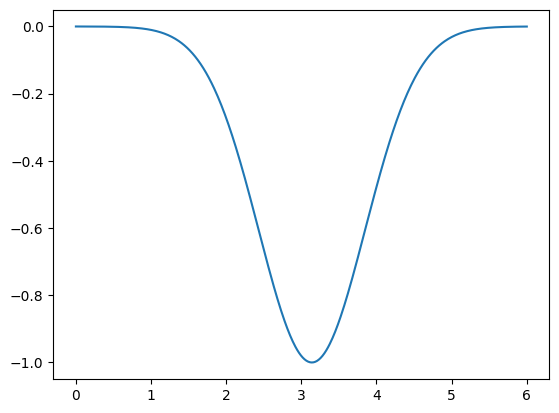

In [ ]:
# (b)
x = np.linspace(0,6,500)  # from 0 to 6 with 500 points
y = f(x)                     # same dimension

plt.plot(x, y)
plt.show()

# From the figure we can see that it's around 3,1 where the minimum point is

In [ ]:
# (c)

trajectory_x = [] # For (d)
trajectory_y = [] # For (d)

def grad_descent(x_guess, k, tolerance, max_iter):
  x = x_guess
  for i in range(max_iter): # If max_iter is reached
    x_new = alg3(x, k)
    if np.abs(x_new - x) < tolerance: # If the tolerance is reached
      break
    x = x_new
    trajectory_x.append(x)    # For (d)
    trajectory_y.append(f(x)) # For (d)
  return x  # Return x where it's the lowest

x_guess = 3
k = 0.001
tolerance = 1e-9
max_iter = 10000000

x = grad_descent(x_guess, k, tolerance, max_iter)
print(f'The minimum point is when x = {x}\nThe value at f({x}) = {f(x)}')

The minimum point is when x = 3.1390000004390384
The value at f(3.1390000004390384) = -0.9999990000013781


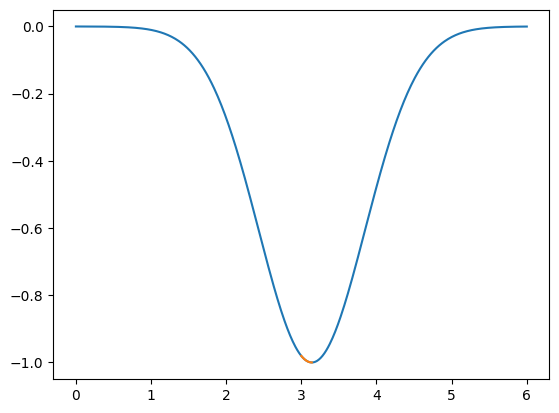

In [ ]:
# (d)
x = np.linspace(0,6,500)  # from 0 to 6 with 500 points
y = f(x)                  # same dimension
plt.plot(x, y)
plt.plot(trajectory_x, trajectory_y)
plt.show()

If the equation would've been positive and we need to find the maximum point I would change algorithm 3. If we instead make change from:
```
<!-- def alg3(x, n):   # Algorithm 3
  x -= n*f(x)
  return x -->
```
to a positive incline:
```
def alg3(x, n):   # Algorithm 3
  x += n*f(x)
  return x
```
Note that there's a plus sign infront the x value.



# **TASK C**

In [ ]:
# Exercise C.1
import torch
from torch import autograd
import numpy as np

def f(x):
  return (x-1)**4 + 3

def f_prime(x):
  return 4*(x-1)**3


  # (1)

print(f(2))         # f(2) = 4
print(f_prime(2))   # f_prime(2) = 4


  # (2)

x = torch.tensor(2.0, requires_grad=True)
y = f(x)
y.backward()
print(int(x.grad.item()))   # 4


  # (3)
# It's the same

4
4
4


In [ ]:
# Exercise C.2

# Implementing function f(z)=1+z+z**2 using for-loop
def f_loop(z):
  start = 0
  stop_plus_one = 3
  step = 1
  n_values = np.arange(start, stop_plus_one, step)
  s = 0
  for i in n_values:
    s = s+torch.pow(z, i)
    i += 1
  return s

z0 = torch.tensor(2.0, requires_grad=True)
fz0 = f_loop(z0)
fz0.backward()
print(z0.grad.item())

5.0


In [ ]:
# Exercise C.3

def f(x, y, z):
  return x*y + x*z + y*z + x**2 + torch.exp(y) + z*torch.sin(x)


# (a)

# df/dx = y + z + 2x + 2cos(x)
def f_prime_x(x, y, z):
  return y + z + 2*x + 2*torch.cos(x)

# df/dy = x + z + exp(y)
def f_prime_y(x, y, z):
  return x + z + torch.exp(y)

# df/dz = x + y + sin(x)
def f_prime_z(x, y, z):
  return x + y + torch.sin(x)


# (b)

x = torch.tensor(torch.pi, requires_grad=True)
y = torch.tensor(2.0, requires_grad=True)
z = torch.tensor(2.0, requires_grad=True)

dfdx = f_prime_x(x, y, z)
dfdy = f_prime_y(x, y, z)
dfdz = f_prime_z(x, y, z)

# print(dfdx.item())    # 8.283185958862305
# print(dfdy.item())    # 12.530649185180664
# print(dfdz.item())    # 5.141592979431152


# (c)

dfdx_autograd = autograd.grad(f(x, y, z), x)
dfdy_autograd = autograd.grad(f(x, y, z), y)
dfdz_autograd = autograd.grad(f(x, y, z), z)

print(dfdx_autograd[0].item())    # 8.283185958862305
print(dfdy_autograd[0].item())    # 12.530649185180664
print(dfdz_autograd[0].item())    # 8.283185958862305


# (d)

# The values are the same for both methods and by hand.
# It's the same as the correct values

8.283185958862305
12.530649185180664
5.141592502593994


In [ ]:
# Exercise C.4

def f(x):
  one_vector = torch.ones_like(x)
  return (x - one_vector).T @ (x - one_vector)

x0 = torch.zeros(size=[4], requires_grad=True)
x1 = torch.ones_like(x0, requires_grad=True)
x2 = torch.tensor([1.5, 1.5, 1.5, 1.5], requires_grad=True)

# print(x0) # tensor([0., 0., 0., 0.], requires_grad=True)
# print(x1) #tensor([1., 1., 1., 1.], requires_grad=True)
# print(x2) #tensor([1.5, 1.5, 1.5, 1.5], requires_grad=True)

fx0 = f(x0)
fx1 = f(x1)
fx2 = f(x2)

print(fx0) # tensor(0.)
print(fx1) # tensor(0.)
print(fx2) # tensor(0.)

fx0.backward()
fx1.backward()
fx2.backward()

x0_grad = x0.grad
x1_grad = x1.grad
x2_grad = x2.grad

print(x0_grad)  # tensor([-2., -2., -2., -2.])
print(x1_grad)  # tensor([0., 0., 0., 0.])
print(x2_grad)  # tensor([1., 1., 1., 1.])

tensor(4., grad_fn=<DotBackward0>)
tensor(0., grad_fn=<DotBackward0>)
tensor(1., grad_fn=<DotBackward0>)
tensor([-2., -2., -2., -2.])
tensor([0., 0., 0., 0.])
tensor([1., 1., 1., 1.])


# **TASK D**

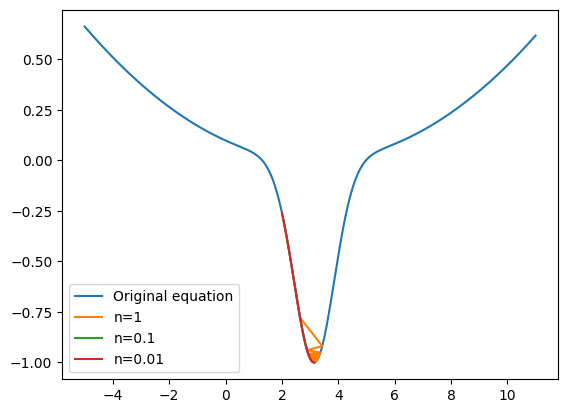

In [ ]:
import torch
from torch import autograd
import matplotlib.pyplot as plt
# import numpy as np

def f(x):
  return -1*torch.exp(-(x-torch.pi)**2) + 0.01*(x-torch.pi)**2

def grad_descent(x, n_i, max_iter, tolerance):
  x_previous = x.clone()
  for i in range(max_iter):

    fx = f(x)
    fx.backward()

    with torch.no_grad():
      x -= n_i * x.grad

    trajectory_x.append(x.clone().item())
    trajectory_y.append(f(x).item())

    x.grad.zero_()
    if torch.abs(x_previous - x) < tolerance:
      break
    x_previous = x.clone()
  return x


x = torch.linspace(-5,11,1000)
y = f(x)
plt.plot(x, y, label="Original equation")
# plt.show

n = [1, 0.1, 0.01]      # steplength
max_iter = 10000        # stoppingcriteria
tolerance = 1e-6        # stoppingcriteria

for n_i in n:
  x = torch.tensor(2., requires_grad=True)
  trajectory_x = []
  trajectory_y = []

  grad_descent(x, n_i, max_iter, tolerance)
  plt.plot(trajectory_x, trajectory_y, label=f'n={n_i}')

plt.legend()
plt.show()

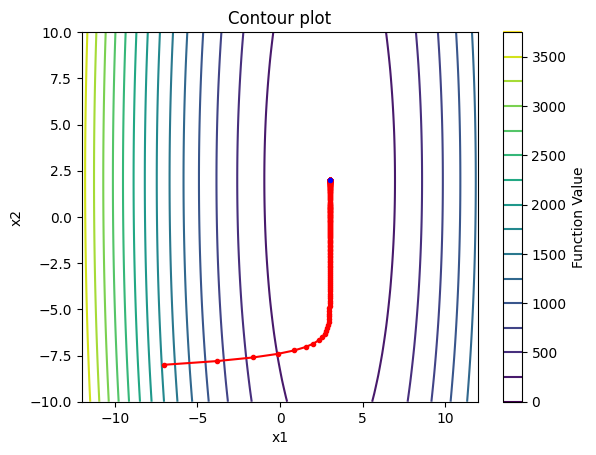

In [ ]:
import torch
from torch import autograd
import matplotlib.pyplot as plt
import numpy as np

def f(x1, x2):
    return (4*(x1-3))**2 + (x2-2)**2

def f_torch(x):
    x1 = x[0]
    x2 = x[1]
    return torch.pow(4*(x1-3), 2) + torch.pow(x2-2, 2)

# Global minimum point at {x1=3, x2=2}

x = torch.tensor([-7.0, -8.0], dtype=torch.float64, requires_grad=True)
n = [0.01, 0.03, 0.1, 1]
max_iter = 100
trajectory_x1=[]
trajectory_x2=[]
trajectory_y=[]

for n_i in n:
    for i in range(max_iter):
        fx = f_torch(x)

        x_np = x.detach().numpy()
        trajectory_x1.append(x_np[0])
        trajectory_x2.append(x_np[1])

        y_np = fx.detach().numpy()
        trajectory_y.append(y_np)

        fx.backward()

        with torch.no_grad():
            x -= n_i * x.grad

        x.grad.zero_()

c = 100
x_plt = np.linspace(-12, 12, c)
y_plt = np.linspace(-10, 10, c)

Z = np.empty([c, c])
for i in range(c):
    for j in range(c):
        Z[j,i] = f(x_plt[i], y_plt[j])

contour_plot = plt.contour(x_plt, y_plt, Z, levels=15, cmap='viridis')
plt.colorbar(contour_plot, label='Function Value')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Contour plot')

plt.plot(trajectory_x1, trajectory_x2, marker='.', linestyle='-', color='red', label='Trajectory')
plt.plot(3, 2, marker='.', linestyle='-', color='blue', label='Optimum')
plt.show()

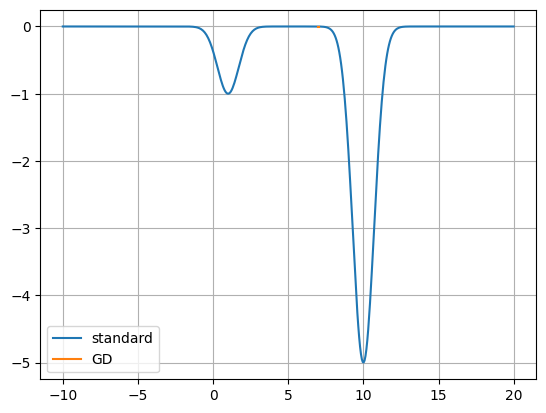

In [ ]:
import torch
import matplotlib.pyplot as plt

def f(x):
    return -torch.exp(-(x - 1)**2) - 5 * torch.exp(-(x - 10)**2)

#x = torch.linspace(-10, 20, 500)
#y = f(x)
#plt.plot(x, y)
#plt.show()
#difficulties because of 2 min, will stop after

def GD(x, n, nr_steps, T):
  x_prev = x.clone()

  for i in range(nr_steps) :
    fx = f(x)
    fx.backward ()
    with torch.no_grad () :
      x -= n*x.grad # needs to be written like this
    x.grad.zero_()
    trajectory_x.append(x.clone().item())
    trajectory_y.append(f(x).item())

    if torch.abs(x - x_prev) < T:
      break
    x_prev = x.clone()
  return x


x = torch.linspace(-10,20,500)
y = f(x)
plt.plot(x, y, label="standard")

''' n = [1, 0.1, 0.01]
for i in n:
  x = torch.tensor(1., requires_grad=True)
  trajectory_x = []
  trajectory_y = [] '''
x = torch.tensor(7., requires_grad=True)
trajectory_x = []
trajectory_y = []
GD(x, 0.01, 1000, 1e-9)
plt.plot(trajectory_x, trajectory_y, label='GD')
plt.grid()
plt.legend()
plt.show()

#c -1 looks like a good starting point
#d, 3 ends up int the first min and 7 ends up in the second min
#e didnt work in both of the cases